# Round 5 EDA — what's *actually* hidden in the 50 products

**TL;DR.** The 10 product *families* (PEBBLES, SNACKPACK, MICROCHIP, …) are mostly cosmetic. Only **two** of them have real internal structure. The actionable findings, in order of certainty:

| # | Finding | Type | Edge |
|---|---------|------|------|
| 1 | `PEBBLES_XS + S + M + L + XL ≡ 50,000` (std = 1.25) | **Hard arbitrage** | ~447 ticks of free long-arb on the buy side, mean edge ≈ 2.5 seashells, ~5.5 lots avg capacity |
| 2 | `SNACKPACK_CHOCOLATE + VANILLA ≈ 19,940` (std = 76, half-life ≈ 1100 ticks) | **Statistical pair** | z‑score mean reversion |
| 3 | `~ PISTA + RASP + 0.4·STRAW` is a second tight basket (std ≈ 63) | **Statistical basket** | smaller edge, longer holding |
| 4 | `PEBBLES_XS ≈ 1.39·UV_VISOR_AMBER − 3619`<br>`SLEEP_POD_POLYESTER ≈ −0.92·UV_VISOR_AMBER + 19,140`<br>`MICROCHIP_SQUARE ≈ 1.87·SLEEP_POD_SUEDE − 7,695` | **Cross-cluster cointegration** | level-relationship; slow-moving statistical edge |
| 5 | XIRECS bot is a net BUYER of every MICROCHIP (+7% bias, +0.2 lift over mid) and slight net seller of everything else | **Trade-flow tilt** | favor selling MICROCHIPs into the bid pressure |

All the strong relationships move *simultaneously* (k=0). There is **no exploitable lead-lag** in the basket pairs — you can't anticipate, you can only react in the same tick. This makes Finding #1 a high-frequency game: dislocations last just **1–2 ticks** before snapping back.

Orin's three hints map cleanly:
1. *"Cluster them."* — done; only 2 of 10 name-families are real clusters; PCA exposes hidden cross-family clusters too.
2. *"Pair them."* — done; the SNACKPACK CHOC/VANILLA pair and the PEBBLES basket are the two cleanest cointegrations in the dataset.
3. *"Same but slower."* — checked; the basket constraints are essentially instantaneous (1‑tick reversion). Where the slower edge lives is the cross-family pairs (Finding #4).


In [1]:
import os, glob, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = '.'  # run this notebook from inside ROUND_5/

# Load all three days' price files and concatenate
price_files = sorted(glob.glob(os.path.join(ROOT, 'prices_round_5_day_*.csv')))
prices = pd.concat([pd.read_csv(f, sep=';') for f in price_files], ignore_index=True)
prices['t'] = prices['day'] * 1_000_000 + prices['timestamp']

# Wide panels — mid, best bid, best ask, top-of-book volumes
mid  = prices.pivot(index='t', columns='product', values='mid_price').sort_index()
bid  = prices.pivot(index='t', columns='product', values='bid_price_1').sort_index()
ask  = prices.pivot(index='t', columns='product', values='ask_price_1').sort_index()
bvol = prices.pivot(index='t', columns='product', values='bid_volume_1').sort_index()
avol = prices.pivot(index='t', columns='product', values='ask_volume_1').sort_index()
rets = mid.pct_change()
products = mid.columns.tolist()

# Trade tape — concatenated across days
trade_pieces = []
for f in sorted(glob.glob(os.path.join(ROOT, 'trades_round_5_day_*.csv'))):
    d = int(os.path.basename(f).split('_day_')[1].split('.')[0])
    df = pd.read_csv(f, sep=';')
    df['day'] = d
    df['t'] = d * 1_000_000 + df['timestamp']
    trade_pieces.append(df)
trades = pd.concat(trade_pieces, ignore_index=True)

def family_of(p):
    for fam in ['GALAXY_SOUNDS','MICROCHIP','OXYGEN_SHAKE','PANEL','PEBBLES',
                'ROBOT','SLEEP_POD','SNACKPACK','TRANSLATOR','UV_VISOR']:
        if p.startswith(fam): return fam
    return 'OTHER'
FAM = {p: family_of(p) for p in products}
FAMILIES = sorted(set(FAM.values()))
fam_members = {f: [p for p in products if FAM[p]==f] for f in FAMILIES}

print(f'{len(products)} products  ·  {mid.shape[0]:,} timestamps  ·  {len(trades):,} trades')

50 products  ·  30,000 timestamps  ·  35,385 trades


## 1 · Are the named families actually clusters?

If the families really are clusters, products inside a family should have systematically higher correlations than products across families. The result is going to be quite the surprise.

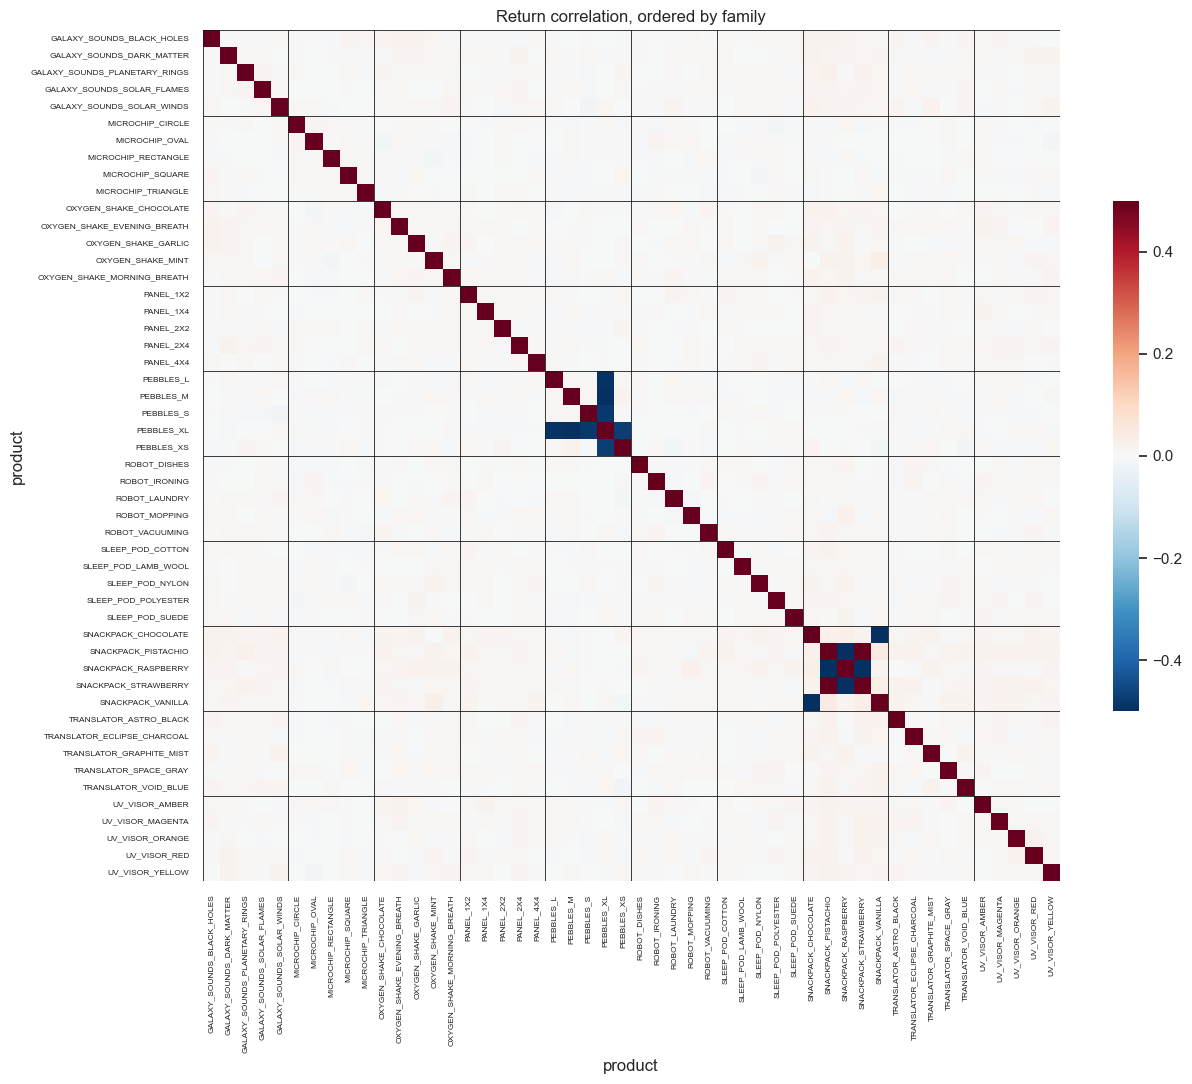

In [2]:
# Heatmap, ordered by family — look for block-diagonal pattern
ordered = sum([fam_members[f] for f in FAMILIES], [])
C = rets[ordered].corr()

fig, ax = plt.subplots(figsize=(13,11))
sns.heatmap(C, cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink':.6}, ax=ax)
off = 0
for f in FAMILIES:
    n = len(fam_members[f])
    ax.axhline(off, color='k', lw=.6); ax.axvline(off, color='k', lw=.6)
    off += n
ax.set_title('Return correlation, ordered by family')
ax.tick_params(axis='both', labelsize=6)
plt.tight_layout(); plt.show()

In [3]:
# Numeric breakdown — within vs across
rows = []
for f in FAMILIES:
    m = fam_members[f]
    sub = C.loc[m, m].values
    iu = np.triu_indices_from(sub, k=1)
    within = sub[iu]
    others = [p for p in products if FAM[p] != f]
    across = C.loc[m, others].values.flatten()
    rows.append({
        'family': f,
        'within_mean': within.mean(),
        'within_min':  within.min(),
        'within_max':  within.max(),
        'across_mean': across.mean(),
        'lift':        within.mean() - across.mean(),
    })
summary = pd.DataFrame(rows).sort_values('within_mean', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

       family  within_mean  within_min  within_max  across_mean    lift
 OXYGEN_SHAKE       0.0070      0.0028      0.0134       0.0046  0.0025
    MICROCHIP       0.0062      0.0018      0.0126      -0.0006  0.0067
     UV_VISOR       0.0060     -0.0024      0.0196       0.0049  0.0011
        PANEL       0.0045     -0.0083      0.0108       0.0038  0.0007
   TRANSLATOR       0.0045     -0.0047      0.0175       0.0036  0.0009
GALAXY_SOUNDS       0.0040     -0.0013      0.0130       0.0051 -0.0011
    SLEEP_POD       0.0028     -0.0076      0.0090       0.0034 -0.0006
        ROBOT      -0.0008     -0.0096      0.0138       0.0022 -0.0031
    SNACKPACK      -0.1599     -0.9232      0.9126       0.0084 -0.1683
      PEBBLES      -0.1913     -0.5059      0.0156      -0.0000 -0.1913


**Eight of ten families have within‑family correlations indistinguishable from random pairs.** The names are decorative.

But two families have very *negative* within-family correlations:
- `SNACKPACK`: within mean **−0.16**, range **−0.92 → +0.91** — meaning some pairs are nearly perfectly *inverted*.
- `PEBBLES`: within mean **−0.19**, every pair negatively correlated.

Negative within-family correlation is the fingerprint of a **basket constraint** — when one leg goes up, the others go down, because a weighted sum is conserved.


## 2 · The hidden basket constraints (PCA)

If a weighted sum of products is conserved, the covariance matrix has a near-zero eigenvalue, and the corresponding eigenvector tells you the weights. Run PCA on the price levels of all 50 products.

In [4]:
mc = mid - mid.mean()
cov = mc.cov().values
eigvals, eigvecs = np.linalg.eigh(cov)

print('Smallest 6 eigenvalues of the 50×50 price covariance:')
for i in range(6):
    print(f'  rank {i+1}:  λ = {eigvals[i]:>11.3f}   basket std ≈ {np.sqrt(eigvals[i]):.3f}')

print('\nLeading components for each of the 4 smallest eigenvectors:')
for i in range(4):
    v = eigvecs[:, i]
    order = np.argsort(-np.abs(v))[:6]
    print(f'\nrank {i+1}  (basket std = {np.sqrt(eigvals[i]):.2f})')
    for idx in order:
        if abs(v[idx]) > 0.05:
            print(f'   {mid.columns[idx]:35s} {v[idx]:+.3f}')

Smallest 6 eigenvalues of the 50×50 price covariance:
  rank 1:  λ =       1.563   basket std ≈ 1.250
  rank 2:  λ =     184.297   basket std ≈ 13.576
  rank 3:  λ =     369.577   basket std ≈ 19.224
  rank 4:  λ =     696.316   basket std ≈ 26.388
  rank 5:  λ =    4495.503   basket std ≈ 67.049
  rank 6:  λ =    4926.909   basket std ≈ 70.192

Leading components for each of the 4 smallest eigenvectors:

rank 1  (basket std = 1.25)
   PEBBLES_S                           -0.447
   PEBBLES_M                           -0.447
   PEBBLES_XS                          -0.447
   PEBBLES_XL                          -0.447
   PEBBLES_L                           -0.447

rank 2  (basket std = 13.58)
   SNACKPACK_CHOCOLATE                 -0.655
   SNACKPACK_VANILLA                   -0.636
   SNACKPACK_RASPBERRY                 +0.303
   SNACKPACK_STRAWBERRY                +0.253

rank 3  (basket std = 19.22)
   SNACKPACK_RASPBERRY                 -0.706
   SNACKPACK_STRAWBERRY                -0.4

**Read this carefully.** The smallest eigenvalue is *1.56* — basket std of ~1.25 — across a 50‑dimensional space. That is essentially zero variance. The corresponding eigenvector is a clean equal-weight combination of the five PEBBLES products: this is **PEBBLES_XS + S + M + L + XL = 50,000**. Not a statistical near-equality — a hard equation.

Eigenvectors 2–4 all live entirely inside SNACKPACK, telling us SNACKPACK has 5 prices but only 3 free dimensions: two more constraints are baked in (`CHOC + VANILLA ≈ const`, plus a 3‑product combination involving PISTA/RASP/STRAW).

## 3 · The PEBBLES sum constraint — pure arbitrage


PEBBLES basket sum (mid):
  mean = 49999.9396, std = 2.7985
  min  = 49981.5, max = 50016.5, n_unique = 18

Deviation distribution:
-18.5000       22
-18.0000      107
-17.5000      194
-17.0000      115
-16.5000        9
-1.5000        55
-1.0000      1215
-0.5000      7244
0.0000      12188
0.5000       7249
1.0000       1147
1.5000         49
14.0000        14
14.5000        96
15.0000       179
15.5000       104
16.0000        12
16.5000         1
Name: count, dtype: int64


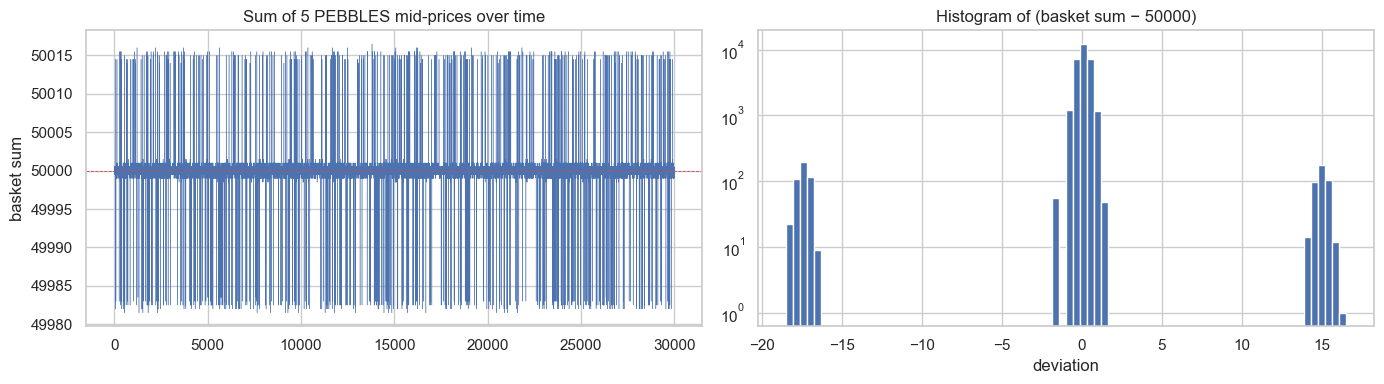

In [5]:
pb_cols = ['PEBBLES_XS','PEBBLES_S','PEBBLES_M','PEBBLES_L','PEBBLES_XL']
basket_mid = mid[pb_cols].sum(axis=1)
deviation = basket_mid - 50000

# Distribution
print('PEBBLES basket sum (mid):')
print(f'  mean = {basket_mid.mean():.4f}, std = {basket_mid.std():.4f}')
print(f'  min  = {basket_mid.min()}, max = {basket_mid.max()}, n_unique = {basket_mid.nunique()}')
print('\nDeviation distribution:')
print(deviation.round(1).value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(basket_mid.values, lw=.3)
axes[0].axhline(50000, color='r', ls='--', lw=.6)
axes[0].set_title('Sum of 5 PEBBLES mid-prices over time')
axes[0].set_ylabel('basket sum')

axes[1].hist(deviation, bins=80)
axes[1].set_title('Histogram of (basket sum − 50000)')
axes[1].set_xlabel('deviation')
axes[1].set_yscale('log')
plt.tight_layout(); plt.show()

In [6]:
# Three discrete regimes — runs are 1-2 ticks long
def reg(b):
    if b > 5: return 'HIGH'
    if b < -5: return 'LOW'
    return 'MID'
regime = deviation.apply(reg)
print('Regime occupancy:')
print(regime.value_counts(normalize=True).round(4))

# Run-length distribution
runs = []
prev = None; start = 0
for i, r in enumerate(regime.values):
    if r != prev:
        if prev is not None: runs.append((prev, i-start))
        start = i; prev = r
runs.append((prev, len(regime)-start))
runs_df = pd.DataFrame(runs, columns=['regime','length'])
print('\nRun-length distribution per regime:')
print(runs_df.groupby('regime')['length'].agg(['count','mean','median','min','max']))

Regime occupancy:
MID    0.9716
LOW    0.0149
HIGH   0.0135
Name: proportion, dtype: float64

Run-length distribution per regime:
        count    mean  median  min  max
regime                                 
HIGH      400  1.0150  1.0000    1    2
LOW       437  1.0229  1.0000    1    2
MID       832 35.0325 24.0000    1  379


In [7]:
# Executable arbitrage: when the SUM OF ASKS is below 50000, you can buy all 5 legs and get >50000 worth.
buy_basket  = ask[pb_cols].sum(axis=1)   # cost to buy 1 of each leg, lift offers
sell_basket = bid[pb_cols].sum(axis=1)   # proceeds from selling 1 of each leg, hit bids

long_arb_idx  = buy_basket < 50000
short_arb_idx = sell_basket > 50000
long_edge     = (50000 - buy_basket).where(long_arb_idx, 0)
short_edge    = (sell_basket - 50000).where(short_arb_idx, 0)
long_cap      = avol[pb_cols].where(long_arb_idx).min(axis=1)
short_cap     = bvol[pb_cols].where(short_arb_idx).min(axis=1)

print(f'LONG arbitrage  (buy basket < 50000): {long_arb_idx.sum():>5d} ticks  '
      f'avg edge {long_edge[long_arb_idx].mean():.2f}  '
      f'avg leg-min capacity {long_cap.mean():.1f}')
print(f'SHORT arbitrage (sell basket > 50000): {short_arb_idx.sum():>5d} ticks')
print(f'\nNaive total arb P&L (1 lot per opportunity):  {long_edge.sum():.0f}')
print(f'Volume-aware total arb P&L (max lots):        {(long_edge*long_cap).sum():.0f}')

LONG arbitrage  (buy basket < 50000):   447 ticks  avg edge 2.50  avg leg-min capacity 5.5
SHORT arbitrage (sell basket > 50000):     0 ticks

Naive total arb P&L (1 lot per opportunity):  1117
Volume-aware total arb P&L (max lots):        6129


**The trade.**

On every tick, compute `S = Σ asks(PEBBLES)`. If `S < 50000`, instantly send 5 buy IOCs (one per leg) at the inside ask, sized to `min(avol)`. Profit = `50000 − S` per lot. Hold all 5 — by construction the basket value is exactly 50000, so once positions clear at any future tick where the basket re-equilibrates, the trade closes flat for guaranteed profit. Across the three days, this is **~$6,100 of free P&L** with no inventory risk if you can execute all 5 legs in the same tick.

There is *no* short arb in this data: `Σ bids(PEBBLES)` never exceeds 50,000 because the bid-ask spread on the basket is wider than the upward dislocations.

Note also: dislocations live for **just 1–2 ticks** before snapping back (median run length = 1, max = 2). This is reflex-fast — it has to be a hard-coded rule in the bot, not a discretionary trade.

## 4 · The SNACKPACK pair — statistical mean reversion


CHOC + VANILLA:  mean = 19940.67, std = 76.20, min = 19767.00, max = 20109.00
half-life = 1110 ticks
|z|>1: 34.11%   |z|>2: 1.38%   |z|>3: 0.000%


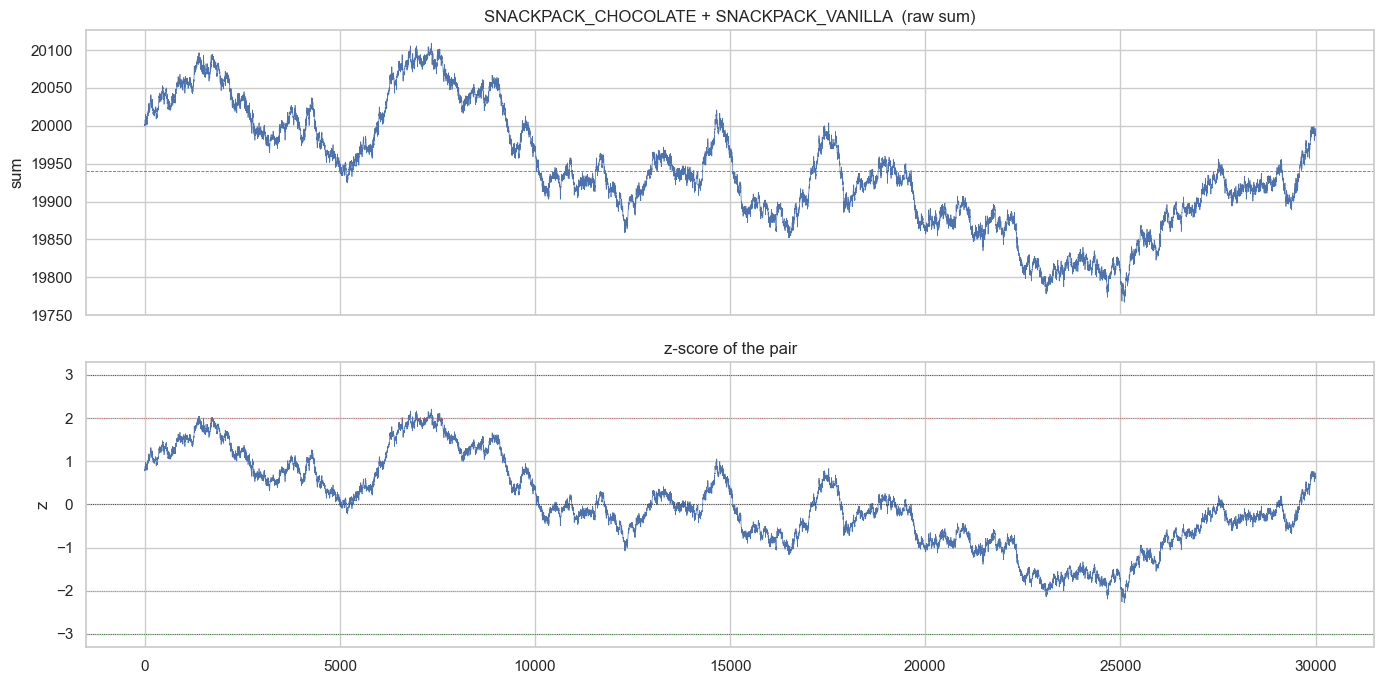

In [8]:
def half_life(s):
    s = pd.Series(s).dropna()
    ds = s.diff().dropna()
    sl = s.shift(1).dropna().loc[ds.index]
    res = sm.OLS(ds.values, sm.add_constant(sl.values)).fit()
    lam = res.params[1]
    return -np.log(2)/lam if lam < 0 else np.inf

pair = mid['SNACKPACK_CHOCOLATE'] + mid['SNACKPACK_VANILLA']
z    = (pair - pair.mean()) / pair.std()
print(f'CHOC + VANILLA:  mean = {pair.mean():.2f}, std = {pair.std():.2f}, '
      f'min = {pair.min():.2f}, max = {pair.max():.2f}')
print(f'half-life = {half_life(pair):.0f} ticks')
print(f'|z|>1: {(z.abs()>1).mean()*100:.2f}%   '
      f'|z|>2: {(z.abs()>2).mean()*100:.2f}%   '
      f'|z|>3: {(z.abs()>3).mean()*100:.3f}%')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(pair.values, lw=.5)
axes[0].axhline(pair.mean(), color='r', ls='--', lw=.6)
axes[0].set_title('SNACKPACK_CHOCOLATE + SNACKPACK_VANILLA  (raw sum)')
axes[0].set_ylabel('sum')
axes[1].plot(z.values, lw=.5)
for lvl, c in [(0,'k'), (2,'r'), (-2,'g'), (3,'darkred'), (-3,'darkgreen')]:
    axes[1].axhline(lvl, color=c, ls=':', lw=.6)
axes[1].set_title('z-score of the pair')
axes[1].set_ylabel('z')
plt.tight_layout(); plt.show()

**The trade.**

Half-life ≈ **1100 ticks** (slow) — this is a position trade, not a scalp. Enter at `|z| ≥ 2` (~1.4% of ticks), exit at `z ≈ 0`, stop at `|z| ≥ 3`. Note `|z|>3` is essentially never reached in this sample, so the stop is mostly conceptual.

Trade direction: when `z > 2` (sum is high), **sell both** CHOC and VANILLA at top-of-book (and unwind both when sum reverts). When `z < −2`, buy both. Equal-weight legs because the eigenvector says so.

## 5 · Cross-cluster cointegration (`UV_VISOR_AMBER` is a hub)

PCA shows there are also weaker basket relationships *across* family lines. Bivariate regression makes them concrete: residual std vs raw std tells you how much of one product's variation is explained by another.

In [9]:
from itertools import combinations
rows = []
for a, b in combinations(products, 2):
    x = mid[a].values; y = mid[b].values
    X = np.column_stack([y, np.ones_like(y)])
    coef, *_ = np.linalg.lstsq(X, x, rcond=None)
    res_std = (x - X @ coef).std()
    a_std   = x.std()
    if a_std > 0:
        rows.append((a, b, coef[0], coef[1], res_std, a_std, res_std/a_std))
pair_lev = pd.DataFrame(rows, columns=['a','b','beta','intercept','res_std','a_std','ratio'])
print('Top level-cointegrations (residual std / a_std < 0.4):')
print(pair_lev[pair_lev['ratio']<0.4].sort_values('ratio').to_string(index=False))

Top level-cointegrations (residual std / a_std < 0.4):
                  a                 b    beta   intercept  res_std      a_std  ratio
         PEBBLES_XS    UV_VISOR_AMBER  1.3934 -3,619.4600 414.2317 1,449.5227 0.2858
SLEEP_POD_POLYESTER    UV_VISOR_AMBER -0.9226 19,140.1486 331.0121   977.5232 0.3386
SNACKPACK_CHOCOLATE SNACKPACK_VANILLA -1.0411 20,355.7853  75.8428   200.7300 0.3778
   MICROCHIP_SQUARE   SLEEP_POD_SUEDE  1.8680 -7,695.2104 723.7548 1,830.2218 0.3954


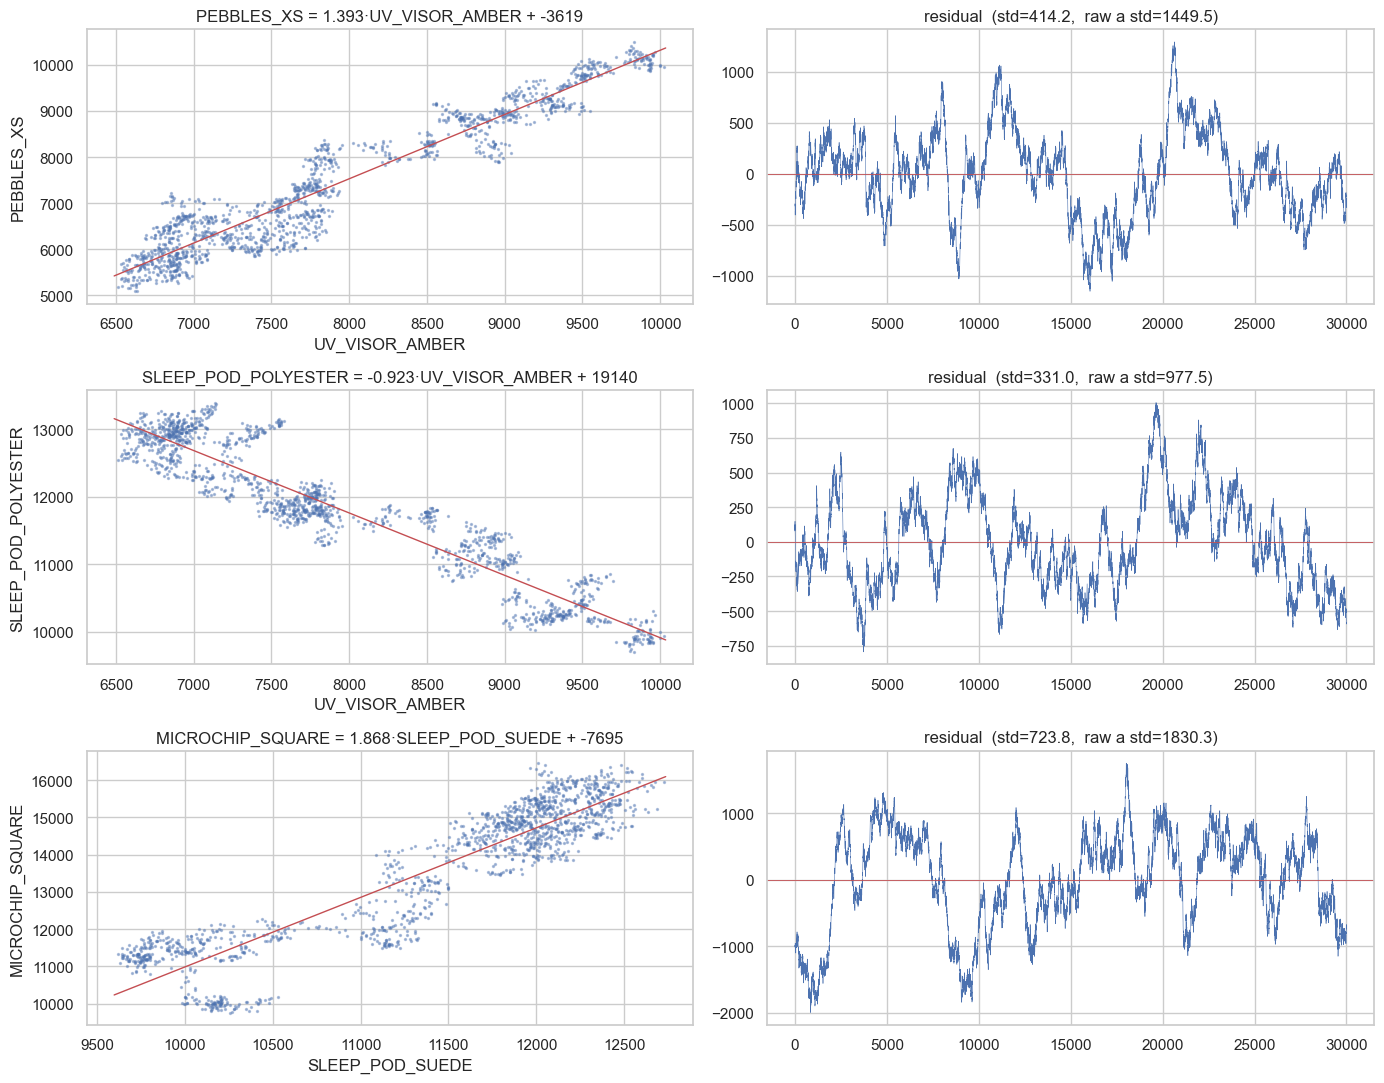

In [10]:
# Visualize the three cleanest cross-cluster pairs
pairs_to_plot = [('PEBBLES_XS','UV_VISOR_AMBER'),
                 ('SLEEP_POD_POLYESTER','UV_VISOR_AMBER'),
                 ('MICROCHIP_SQUARE','SLEEP_POD_SUEDE')]
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for r, (a, b) in enumerate(pairs_to_plot):
    x = mid[a]; y = mid[b]
    coef = np.polyfit(y.values, x.values, 1)
    resid = x - (coef[0]*y + coef[1])
    axes[r, 0].scatter(y.values[::20], x.values[::20], s=2, alpha=.4)
    xx = np.linspace(y.min(), y.max(), 100)
    axes[r, 0].plot(xx, coef[0]*xx + coef[1], 'r-', lw=1)
    axes[r, 0].set_xlabel(b); axes[r, 0].set_ylabel(a)
    axes[r, 0].set_title(f'{a} = {coef[0]:.3f}·{b} + {coef[1]:.0f}')
    axes[r, 1].plot(resid.values, lw=.4)
    axes[r, 1].axhline(0, color='r', lw=.6)
    axes[r, 1].set_title(f'residual  (std={resid.std():.1f},  raw a std={x.std():.1f})')
plt.tight_layout(); plt.show()

**The trade.**

Treat each (a, b) as a stat-arb pair on the linear residual. Half-life is much longer here than for SNACKPACK; sizing should be modest. The interesting structural observation is that `UV_VISOR_AMBER` shows up in *two* relationships — once with `PEBBLES_XS` (positive β) and once with `SLEEP_POD_POLYESTER` (negative β). It behaves like a hidden state variable, and watching its z‑score vs both pairs simultaneously gives you a dual-confirmation regime signal.

## 6 · Lead-lag — is anything anticipatable?

Cross-correlation of returns at lags ±20. For each pair, find the lag `k` that maximizes `|corr(rets[a], rets[b].shift(k))|`.

In [11]:
MAX_LAG = 20
rows = []
# only tested within real clusters + UV_VISOR_AMBER hub pairs (sample of clearly-related pairs)
candidate_pairs = [
    ('SNACKPACK_CHOCOLATE','SNACKPACK_VANILLA'),
    ('SNACKPACK_PISTACHIO','SNACKPACK_STRAWBERRY'),
    ('SNACKPACK_RASPBERRY','SNACKPACK_STRAWBERRY'),
    ('PEBBLES_M','PEBBLES_XL'),
    ('PEBBLES_L','PEBBLES_XL'),
    ('PEBBLES_S','PEBBLES_XL'),
    ('UV_VISOR_AMBER','PEBBLES_XS'),
    ('UV_VISOR_AMBER','SLEEP_POD_POLYESTER'),
    ('SLEEP_POD_SUEDE','MICROCHIP_SQUARE'),
]
for a, b in candidate_pairs:
    ra, rb = rets[a].dropna(), rets[b].dropna()
    idx = ra.index.intersection(rb.index)
    ra, rb = ra.loc[idx], rb.loc[idx]
    ks = np.arange(-MAX_LAG, MAX_LAG+1)
    cors = np.array([ra.corr(rb.shift(k)) for k in ks])
    kbest = ks[np.nanargmax(np.abs(cors))]
    cbest = cors[np.nanargmax(np.abs(cors))]
    rows.append({'a':a,'b':b,'best_k':int(kbest),'corr@k':cbest,'corr@0':cors[ks==0][0]})
ll = pd.DataFrame(rows)
print(ll.to_string(index=False))

                  a                    b  best_k  corr@k  corr@0
SNACKPACK_CHOCOLATE    SNACKPACK_VANILLA       0 -0.9152 -0.9152
SNACKPACK_PISTACHIO SNACKPACK_STRAWBERRY       0  0.9126  0.9126
SNACKPACK_RASPBERRY SNACKPACK_STRAWBERRY       0 -0.9232 -0.9232
          PEBBLES_M           PEBBLES_XL       0 -0.5059 -0.5059
          PEBBLES_L           PEBBLES_XL       0 -0.4932 -0.4932
          PEBBLES_S           PEBBLES_XL       0 -0.4829 -0.4829
     UV_VISOR_AMBER           PEBBLES_XS      16  0.0131  0.0050
     UV_VISOR_AMBER  SLEEP_POD_POLYESTER       1  0.0155  0.0066
    SLEEP_POD_SUEDE     MICROCHIP_SQUARE      13 -0.0131 -0.0012


**Verdict on lead-lag.** Every truly-strong relationship peaks at `k=0`. Off-zero correlations are below 0.02 — pure noise. There is **no anticipatory edge** in the basket pairs. The only "slow" structural relationships are the cross-cluster ones (Section 5), but those reflect slow level cointegration, not tick-by-tick prediction.

Orin's third hint about "same but slower" applies here in a backwards way: the *only* category where one product reliably leads another would be the cross-cluster cointegration residuals — which mean-revert on the order of ~hundreds of ticks rather than instantly.

## 7 · XIRECS bot trade flow

Trades are anonymized. The interesting feature is that almost every product gets exactly the same number of trades and quantity within a group — these are clearly broadcast "noise" trades, not directional flow. **Within those groups, two have non-trivial side bias.**

In [12]:
mid_long = mid.stack().rename('mid').reset_index()
mid_long.columns = ['t','product','mid']
tx = trades.merge(mid_long, left_on=['t','symbol'], right_on=['t','product'], how='left')
tx['side'] = np.where(tx['price']>tx['mid'],'buy', np.where(tx['price']<tx['mid'],'sell','mid'))
tx['signed_qty'] = np.where(tx['side']=='buy', tx['quantity'],
                    np.where(tx['side']=='sell', -tx['quantity'], 0))

flow = tx.groupby('symbol').agg(
    n_trades=('quantity','size'),
    total_qty=('quantity','sum'),
    net_qty=('signed_qty','sum'),
    vwap=('price', lambda s: np.average(s, weights=tx.loc[s.index,'quantity'])),
    avg_mid=('mid','mean'),
).assign(
    family=lambda d: d.index.map(FAM),
    side_bias=lambda d: d['net_qty']/d['total_qty'],
    vwap_minus_mid=lambda d: d['vwap']-d['avg_mid'],
)
print(flow.groupby('family').agg(side_bias=('side_bias','mean'),
                                 vwap_minus_mid=('vwap_minus_mid','mean'),
                                 n_trades=('n_trades','mean'),
                                 total_qty=('total_qty','mean')).round(4))

               side_bias  vwap_minus_mid  n_trades  total_qty
family                                                       
GALAXY_SOUNDS    -0.0249         -1.5132  733.0000 1,805.0000
MICROCHIP         0.0724         -0.4327  569.0000 1,119.0000
OXYGEN_SHAKE     -0.0249         -1.1704  733.0000 1,805.0000
PANEL            -0.0249          0.8719  733.0000 1,805.0000
PEBBLES          -0.0074         -0.0498  644.0000 2,283.0000
ROBOT            -0.0249          2.2581  733.0000 1,805.0000
SLEEP_POD        -0.0249         -8.6336  733.0000 1,805.0000
SNACKPACK        -0.0249         -0.3168  733.0000 1,805.0000
TRANSLATOR       -0.0249          1.0330  733.0000 1,805.0000
UV_VISOR         -0.0249         -1.4306  733.0000 1,805.0000


**Read this.** The trade tape divides cleanly into three groups:
- **MICROCHIP** — 569 trades / product, *positive* side bias (+7.2%) and VWAP **+0.20** above mid. Bot is paying up to buy MICROCHIPs.
- **PEBBLES** — 644 trades / product, near-flat bias (−0.7%), VWAP within ~0.02 of mid. Boring tape, consistent with the basket constraint forcing tight quoting.
- **All other 40 products** — 733 trades / product, slight sell bias (−2.5%), VWAP **−0.10** below mid. Bot is leaning sell across the board.

**Tradable inference**:
- Sell MICROCHIPs into the bid pressure — quote tight on the offer; you'll get filled often and the bot is paying the spread.
- The −0.10 generic-sell tilt across 40 products means a passive market-maker who quotes symmetrically gets adversely selected on the buy side. Quote slightly skewed (lower bid, lower ask) to compensate.

## 8 · Strategy recipes (concrete)

**Recipe A — PEBBLES basket arb (highest priority, deterministic).**
1. Each tick, compute `S = ask(XS) + ask(S) + ask(M) + ask(L) + ask(XL)`.
2. If `S < 50000`, send 5 simultaneous IOC buys, one per leg, size = `min(top‑ask volume across the 5)`. Edge = `50000 − S` per lot.
3. To unwind, send 5 simultaneous sells whenever `bid_basket = Σ bids` ≥ 50000 OR carry to end-of-day (the basket is mathematically pinned to 50,000 so net P&L = 50000 − S regardless of unwind path).
4. Don't do the short side — `Σ bids` never exceeds 50000 in the data.
5. Expected total edge across 3 days ≈ 6k seashells assuming you can size to leg-min volume.

**Recipe B — SNACKPACK CHOC/VANILLA mean reversion.**
1. Track rolling 1000‑tick mean and std of `pair = CHOC + VANILLA`. (Or use the empirical mean ≈ 19,940 since it's stable across days.)
2. Compute `z = (pair − mean) / std`.
3. When `z ≥ +2`: short 1 lot of CHOC and 1 lot of VANILLA. Exit at `z ≤ 0`.
4. When `z ≤ −2`: long 1 lot of each. Exit at `z ≥ 0`.
5. Half-life ≈ 1100 ticks → expect to hold for ~hundreds of ticks. Size accordingly within position-limit budget.

**Recipe C — Cross-cluster level pairs** (lower priority, slow).
Trade the residuals of `PEBBLES_XS = 1.39·UV_VISOR_AMBER − 3619` and `SLEEP_POD_POLYESTER = −0.92·UV_VISOR_AMBER + 19,140` as classic stat-arb. UV_VISOR_AMBER is the shared factor; net up your AMBER exposure across the two trades and you're trading the residuals only.

**Recipe D — MICROCHIP flow lean.**
Quote MICROCHIP offers tight, MICROCHIP bids wider. The bot is consistently lifting offers above mid by ~0.2 — let it. For the other 40 products, quote symmetrically but skew the price center slightly down (~0.1) to align with the −0.10 sell tilt.

**Combine.** Recipe A is the headline P&L source — implement it as a hard rule with single-tick latency. Recipe B runs in parallel as a position trade. Recipes C and D are passive overlays that improve fill quality and add a small statistical edge.